# Preprocessing Transactions

This file preprocesses the transaction data 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys, os, glob
import re
import math
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, LongType, IntegerType, DateType, DoubleType
from datetime import datetime, timedelta

In [2]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/10 15:33:56 WARN Utils: Your hostname, tray, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/09/10 15:33:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/10 15:33:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/10 15:33:58 WARN Utils: Service 'SparkUI' could not bind on

In [3]:
transactions = spark.read.parquet("../data/landing/transactions_20210828_20220227_snapshot")
transactions.show()

+-------+------------+------------------+--------------------+--------------+
|user_id|merchant_abn|      dollar_value|            order_id|order_datetime|
+-------+------------+------------------+--------------------+--------------+
|  14935| 79417999332|136.06570809815838|23acbb7b-cf98-458...|    2021-11-26|
|      1| 46451548968| 72.61581642788431|76bab304-fa2d-400...|    2021-11-26|
|  14936| 89518629617|3.0783487174439297|a2ae446a-2959-41c...|    2021-11-26|
|      1| 49167531725| 51.58228625503599|7080c274-17f7-4cc...|    2021-11-26|
|  14936| 31101120643|25.228114942417797|8e301c0f-06ab-45c...|    2021-11-26|
|      2| 67978471888| 691.5028234458998|0380e9ad-b0e8-420...|    2021-11-26|
|  14936| 60956456424|102.13952056640888|5ac3da9c-5147-452...|    2021-11-26|
|      2| 47644196714| 644.5220654863093|4e368e44-86f8-4de...|    2021-11-26|
|  14938| 39649557865|209.12780951421405|4d78cd01-4bab-494...|    2021-11-26|
|      3| 88402174457| 141.0387993699113|c50c957d-ecfc-430...|  

In [4]:
transactions.write.mode('overwrite').parquet('.././data/landing/transactions/total_transactions')
transactions = spark.read.parquet(".././data/landing/transactions/total_transactions")
transactions.show(truncate = False)

+-------+------------+------------------+------------------------------------+--------------+
|user_id|merchant_abn|dollar_value      |order_id                            |order_datetime|
+-------+------------+------------------+------------------------------------+--------------+
|14935  |79417999332 |136.06570809815838|23acbb7b-cf98-4580-9775-86b8e0a2bd88|2021-11-26    |
|1      |46451548968 |72.61581642788431 |76bab304-fa2d-4004-8179-8638b56a873e|2021-11-26    |
|14936  |89518629617 |3.0783487174439297|a2ae446a-2959-41c4-81fd-a30c1efbde0c|2021-11-26    |
|1      |49167531725 |51.58228625503599 |7080c274-17f7-4ccf-be22-1d33a45f7f81|2021-11-26    |
|14936  |31101120643 |25.228114942417797|8e301c0f-06ab-45cb-a573-47c8e9b95423|2021-11-26    |
|2      |67978471888 |691.5028234458998 |0380e9ad-b0e8-4203-a74b-e4ad3504d643|2021-11-26    |
|14936  |60956456424 |102.13952056640888|5ac3da9c-5147-4524-8efb-0d312cfe6748|2021-11-26    |
|2      |47644196714 |644.5220654863093 |4e368e44-86f8-4dee-

# Schema

In [5]:
transactions.printSchema()

root
 |-- user_id: long (nullable = true)
 |-- merchant_abn: long (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)



Ensure all datatypes are consistent across tables.

In [6]:
transactions = transactions.withColumn('user_id', F.col('user_id').cast(StringType()))
transactions = transactions.withColumn('merchant_abn', F.col('merchant_abn').cast(StringType()))
transactions.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)



# Missing Value Detection

In [7]:
transactions.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in transactions.columns
]).show()

+-------+------------+------------+--------+--------------+
|user_id|merchant_abn|dollar_value|order_id|order_datetime|
+-------+------------+------------+--------+--------------+
|      0|           0|           0|       0|             0|
+-------+------------+------------+--------+--------------+



# Business Filtering Rule

`dollar value` for any transaction needs be greater than 0.

In [8]:
def report_shape(df, label):
    n = df.count()
    print(f"{label}: {n:,} rows")
    return n

n0 = report_shape(transactions, "0. raw transactions")

# --- Business-rule filtering ---
# dollar_value must be strictly positive -- a $0 or negative transaction
# isn't a real purchase (refunds/corrections, if any, aren't modelled here).
step1 = transactions.filter(F.col("dollar_value") > 0)
n1 = report_shape(step1, "1. dollar_value > 0")

clean = step1
print(f"Retained: {n1:,} / {n0:,} ({n1/n0:.1%})")

0. raw transactions: 4,508,106 rows


1. dollar_value > 0: 4,508,106 rows
Retained: 4,508,106 / 4,508,106 (100.0%)


# Outlier Removal

Outlier removal on `dollar_value` (log-N IQR rule). Raw dollar_value is right-skewed (many small purchases, a long tail of large ones), so IQR is computed on log1p(dollar_value) rather than the raw scale. Per the log-N rule: flag values more than k x IQR from the box, where k = sqrt(log n) - 0.5 for n > 100.

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


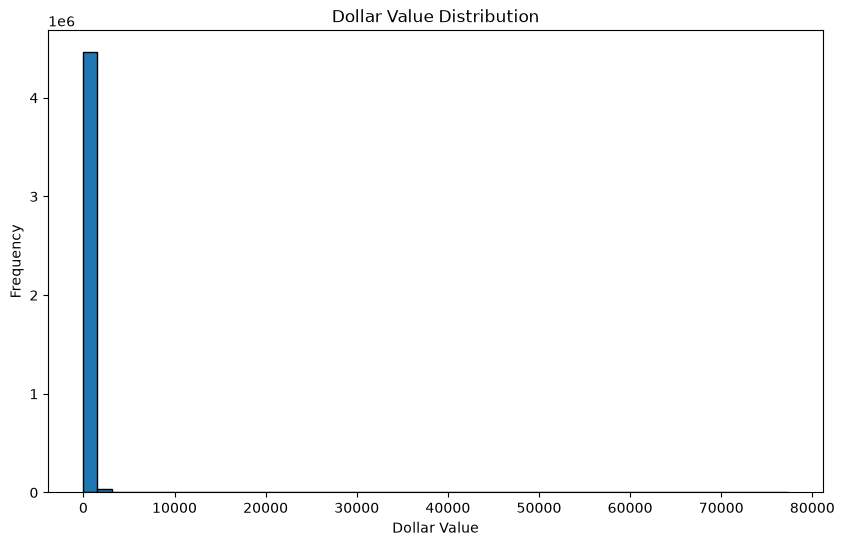

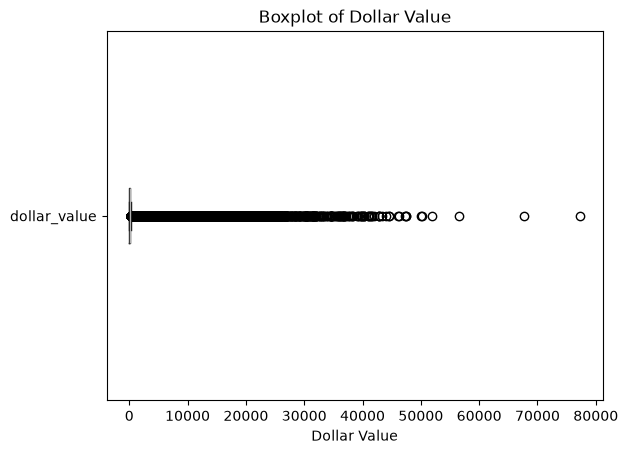

In [9]:
dollar = transactions.select("dollar_value").toPandas()

plt.figure(figsize=(10, 6))
plt.hist(dollar["dollar_value"], bins=50, edgecolor="black")
plt.xlabel("Dollar Value")
plt.ylabel("Frequency")
plt.title("Dollar Value Distribution")
plt.show()

dollar.boxplot(column="dollar_value", vert=False, grid=False)
plt.xlabel("Dollar Value")
plt.title("Boxplot of Dollar Value")
plt.show()

In [10]:
clean = clean.withColumn("log_dollar_value", F.log1p(F.col("dollar_value")))

n_rows = clean.count()
k = np.sqrt(np.log(n_rows)) - 0.5

q1, q3 = clean.approxQuantile("log_dollar_value", [0.25, 0.75], 0.0)
iqr = q3 - q1

lower_bound = q1 - k * iqr
upper_bound = q3 + k * iqr

print(f"n = {n_rows:,}, k = {k:.4f}")
print(f"Log-scale Q1: {q1:.4f}, Q3: {q3:.4f}, IQR: {iqr:.4f}")
print(f"Log-scale bounds: [{lower_bound:.4f}, {upper_bound:.4f}]")

n_before_outlier = report_shape(clean, "2. before outlier removal")

curated = clean.filter(
    (F.col("log_dollar_value") >= lower_bound) &
    (F.col("log_dollar_value") <= upper_bound)
).drop("log_dollar_value")

n_after_outlier = report_shape(curated, "3. after log-N IQR outlier removal")
print(f"Removed as outliers: {n_before_outlier - n_after_outlier:,}")

print(f"\nTotal retained: {n_after_outlier:,} / {n0:,} ({n_after_outlier/n0:.1%})")

n = 4,508,106, k = 3.4143
Log-scale Q1: 3.3003, Q3: 5.0201, IQR: 1.7198
Log-scale bounds: [-2.5714, 10.8918]
2. before outlier removal: 4,508,106 rows
3. after log-N IQR outlier removal: 4,508,103 rows
Removed as outliers: 3

Total retained: 4,508,103 / 4,508,106 (100.0%)


Store curated transaction dataset

In [11]:
transactions.write.mode("overwrite").parquet("../data/curated/transactions/")

In [12]:
spark.read.parquet("../data/curated/df_customers/").printSchema()
spark.read.parquet("../data/curated/df_customers/").count() 

root
 |-- consumer_id: long (nullable = true)
 |-- user_id: long (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)



34864

# Join with Consumers data

Join with `user_id` from transactions and consumers

In [25]:
consumer = spark.read.parquet("../data/curated/df_customers/")
consumer.show(truncate = False)

+-----------+-------+--------------+------------------+---------------------+-----------------+------------------------------+-----+--------+------+
|consumer_id|user_id|order_datetime|fraud_probability |is_same_day_duplicate|name             |address                       |state|postcode|gender|
+-----------+-------+--------------+------------------+---------------------+-----------------+------------------------------+-----+--------+------+
|712975     |5      |2021-10-04    |10.868364868449886|false                |Rebecca Blanchard|9271 Michael Manors Suite 651 |WA   |6355    |Female|
|712975     |5      |2022-01-11    |27.496186536467164|false                |Rebecca Blanchard|9271 Michael Manors Suite 651 |WA   |6355    |Female|
|712975     |5      |2022-02-08    |9.02022421158597  |false                |Rebecca Blanchard|9271 Michael Manors Suite 651 |WA   |6355    |Female|
|1331093    |17     |2022-02-14    |9.518525205093667 |false                |Alyssa Wilson    |44353 Natha

In [26]:
transaction_cols = set(transactions.columns)
consumer_cols = set(consumer.columns)

overlapping_cols = transaction_cols & consumer_cols
print(overlapping_cols)

{'user_id', 'order_datetime'}


In [ ]:
transactions.count()

4508106

In [33]:
consumer_cols_to_add = [
    c for c in consumer.columns
    if c not in transactions.columns
]

df_transactions = (
    transactions
    .join(
        consumer.select("user_id", *consumer_cols_to_add),
        on="user_id",
        how="inner"
    )
)

df_transactions.show()

+-------+------------+------------------+--------------------+--------------+-----------+------------------+---------------------+----------------+--------------------+-----+--------+-----------+
|user_id|merchant_abn|      dollar_value|            order_id|order_datetime|consumer_id| fraud_probability|is_same_day_duplicate|            name|             address|state|postcode|     gender|
+-------+------------+------------------+--------------------+--------------+-----------+------------------+---------------------+----------------+--------------------+-----+--------+-----------+
|  14935| 79417999332|136.06570809815838|23acbb7b-cf98-458...|    2021-11-26|    1059280| 11.04107543972518|                false|   Cameron Adams|0280 Carpenter Lodge|  QLD|    4563|       Male|
|  14935| 79417999332|136.06570809815838|23acbb7b-cf98-458...|    2021-11-26|    1059280|10.622137737727327|                false|   Cameron Adams|0280 Carpenter Lodge|  QLD|    4563|       Male|
|      1| 4645154896

In [34]:
df_transactions.printSchema()
df_transactions.write.mode("overwrite").parquet("../data/curated/df_transactions/")

root
 |-- user_id: string (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)

